## Categorization of Cyber Security Attacks on IOT ##
by Andi (B.A.) Rodríguez Macuacé

In [57]:
#Importing project libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve)


# 1. Descriptive Analysis of Data

In [33]:
# Importing dataset
attacks_data = pd.read_csv("./dataset/RT_IOT2022.csv", sep=",")

# Show data info
print("--- Basic Information ---")
print(attacks_data.info())
print("\n--- Basic Statistics ---")
print(attacks_data.describe())

print("\n--- Number of Attack data samples per Attack_type  ---")
counts = attacks_data.groupby('Attack_type').size()
print(original_counts)

#Checking for missing values
print("\n--- Missing Values ---")
print(attacks_data.isnull().sum())

--- Basic Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  object 
 4   service                   123117 non-null  object 
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_sec          123117 non-null  float64
 12  flow_pkts_per_sec         123117 non-null  float64
 13  down_up_ratio     

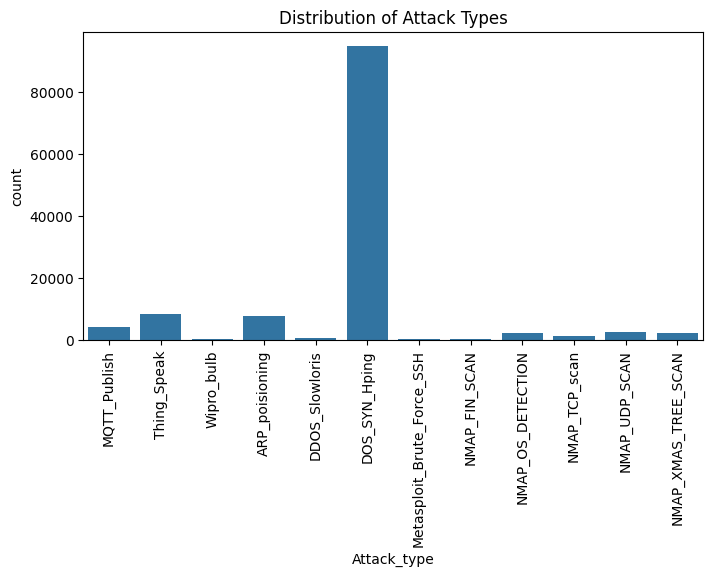

In [24]:
# Visualization of Target Distribution (Attack type)
plt.figure(figsize=(8,4))
sns.countplot(data=attacks_data, x='Attack_type')
plt.title("Distribution of Attack Types")
plt.xticks(rotation=90)
plt.show()

# 2. Implementation of necessary pre-processing

Most attacks in the dataset are type DOS-SYN flood (total of 94659), the large number of samples with this type creates an imbalance that could affect the accuracy of the model when predicting. For this reason, this attack type will be removed from the dataset.

# TO-DO perform a PCA in the dataset to see distribution of the different types.


--- Attacks data samples without DOS_SYN_Hping:  28458  ---
Attack_type
ARP_poisioning                7750
DDOS_Slowloris                 534
MQTT_Publish                  4146
Metasploit_Brute_Force_SSH      37
NMAP_FIN_SCAN                   28
NMAP_OS_DETECTION             2000
NMAP_TCP_scan                 1002
NMAP_UDP_SCAN                 2590
NMAP_XMAS_TREE_SCAN           2010
Thing_Speak                   8108
Wipro_bulb                     253
dtype: int64


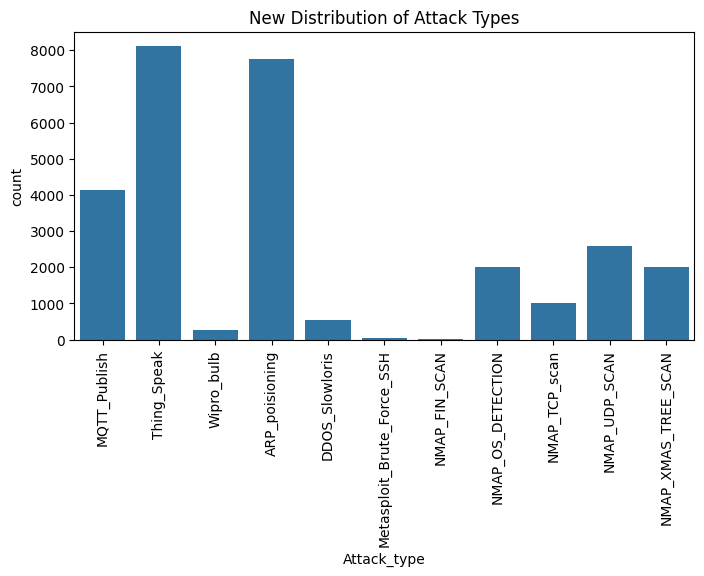

In [32]:
# Remove SYN flood attacks from dataset
filtered_attacks_data = attacks_data.loc[attacks_data['Attack_type'] != 'DOS_SYN_Hping']
filtered_row_count = len(filtered_attacks_data)
print("\n--- Attacks data samples without DOS_SYN_Hping: ",filtered_row_count, " ---")
filtered_counts = filtered_attacks_data.groupby('Attack_type').size()
print(filtered_counts)

# Visualization of New target Distribution (Attack type)
plt.figure(figsize=(8,4))
sns.countplot(data=filtered_attacks_data, x='Attack_type')
plt.title("New Distribution of Attack Types")
plt.xticks(rotation=90)
plt.show()


In [ ]:
#Separating Features and Target
X = filtered_attacks_data.drop('Attack_type', axis=1)
y = filtered_attacks_data['Attack_type']

#Encode text-based features and target
le_target = LabelEncoder()
le_protocol = LabelEncoder()
le_service = LabelEncoder()

y_encoded = le_target.fit_transform(y)
X['proto'] = le_protocol.fit_transform(X['proto'])
X['service'] = le_service.fit_transform(X['service'])


#Split dataset into test and train sets for X and y
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

#Scale the data for feature range normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## this could potentially be turn into a pipeline?
## should consider rebalancing the data so all the types are represented more equally

# 3. Formalisation of the problem

Given real-time IoT network flow data, containing both flow from regular devices, as well as specific attack scenarios with features like packet rates, flow duration, TCP flags and protocols; The proposal is to build a supervised machine learning model that, with the categorical feature attack_type as the target, can classify whether a network flow belongs to a specific cybersecurity attack type or if is malicious at all, given a set of network flow features. Additionally the model will give insight into which features contribute most to its performance.

Multiclass classification would be the method primarily used to achieve this, although a Binary Classification might be applied as well for certain models if it is deemed more efficient and better at predicting.

The evaluation for the model will be done with the metrics: Accuracy, Precision, Recall and F1-Scores to check on imbalance performance; confusion matrix for further analysis and ROC-AUC (possibly checking per class ROC scores)

Guided by the notebooks created in previous labs, several supervised learning algorithims will be used to make predictions, and subsequently compared to see which is more effective. Among the attempted models will be Logistic Regression, KNN, Decision Tree and SVM; as well as any other algorithms discovered through further research.

# 4. Selection of baseline model
Because the problem at hand focuses on (multiclass) classification tasks, the baseline model will be Logistic Regression as it is fast, easy to interpret and overall has a good reputation of performance for this type of cases.

In [63]:
#Initializing Logistic Regression Model
baseline_model = LogisticRegression(max_iter=1000, random_state=42)

#train model
baseline_model.fit(X_train_scaled, y_train)

#Make prediction
y_prediction = baseline_model.predict(X_test_scaled)
y_probability = baseline_model.predict_proba(X_test_scaled)

#Display model performanse
print("Classification Report: \n", classification_report(y_test, y_prediction))

print("\nAccuracy: ", accuracy_score(y_test, y_prediction))
print("\nF1-score: ", f1_score(y_test, y_prediction, average='weighted'))
print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_prediction))
print("\nROC-AUC: ", roc_auc_score(y_test, y_probability, multi_class='ovr'))

Classification Report: 
               precision    recall  f1-score   support

           0       0.95      0.92      0.93      1550
           1       0.94      0.79      0.86       107
           2       1.00      1.00      1.00       829
           3       0.83      0.71      0.77         7
           4       0.83      0.83      0.83         6
           5       1.00      1.00      1.00       400
           6       1.00      0.99      1.00       200
           7       0.96      0.99      0.97       518
           8       1.00      1.00      1.00       402
           9       0.93      0.96      0.94      1622
          10       0.92      0.90      0.91        51

    accuracy                           0.96      5692
   macro avg       0.94      0.92      0.93      5692
weighted avg       0.96      0.96      0.96      5692


Accuracy:  0.9590653548840478

F1-score:  0.9588630699365668

=== Confusion Matrix ===
[[1426    2    0    0    0    0    0    2    0  117    3]
 [   2   85    0

# Prediction Metrics Discussion of first results
The overall performance of the baseline model based on the result metrics is promising, as the accuracy as well as the ROC-AUC score are very close to 1.0. The classification report demonstrates that the model is mostly reliable with classes with big samples, however, it strugles to accurately classify when the sample size is too small. The confusion matrix shows a low number of misclassifications, meaning that it does properly learn very distinct feature patterns. It is concluded, that balancing techniques must be applied during pre-processing of the dataset, in order to achieve precission accross all types. After refining the dataset, the next step is to train the different (relevant) algorithms and compare them amongs each other, in ordert to identify the best fitted for the problem at hand.